In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn import preprocessing as p
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())
es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 3)



Num GPUs Available:  1
True


2023-01-03 12:54:24.957929: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:54:24.990698: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:54:24.991031: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [2]:
from keras.preprocessing.image import ImageDataGenerator

root_path = "Brain Tumor Data Set/Brain Tumor Data Set"

gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    validation_split=0.2
)

# Load Data
train_ds = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    shuffle=True,
    color_mode = "grayscale",
    target_size=(100,100),
    subset="training"
)

valid_ds = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    shuffle=True,
    color_mode = "grayscale",
    target_size=(100,100),
    subset="validation"
)


Found 3681 images belonging to 2 classes.
Found 919 images belonging to 2 classes.


[1. 0.]
[1. 0.]
[0. 1.]
[1. 0.]
[1. 0.]
[1. 0.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[1. 0.]
[0. 1.]
[1. 0.]
[1. 0.]
[0. 1.]
[0. 1.]
[1. 0.]
[0. 1.]
[1. 0.]
[1. 0.]
[1. 0.]
[0. 1.]
[0. 1.]


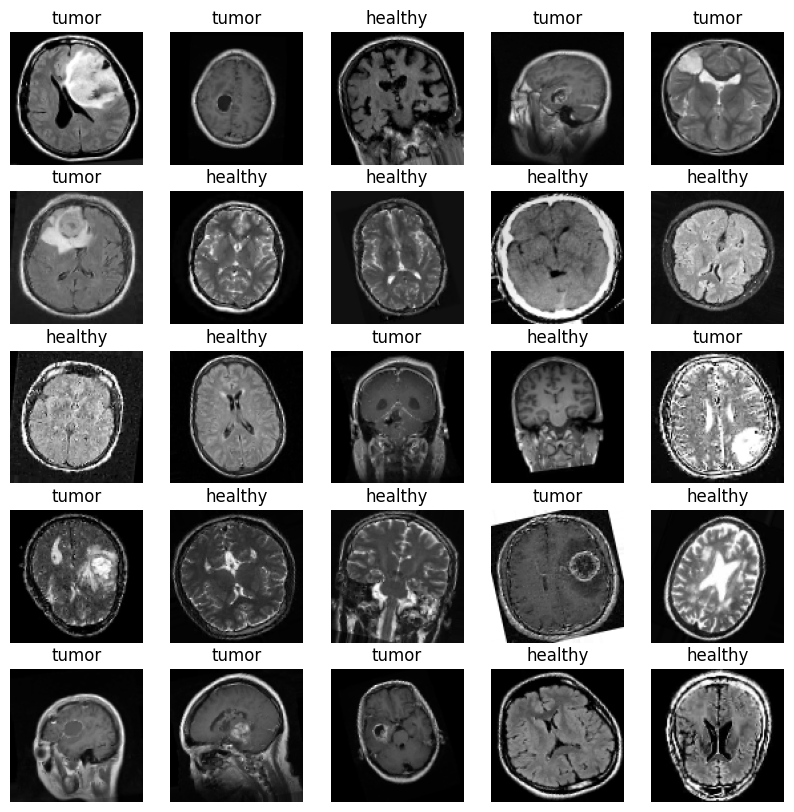

In [3]:
plt.figure(figsize=(10,10))
img, label = train_ds.next()
for i in range(1,26):
    print(label[i])
    plt.subplot(5,5,i)
    plt.imshow(img[i], cmap="gray")
    plt.axis('off')
    if label[i][0]==1:
        plt.title("tumor")
    else:
        plt.title("healthy")
    
    

In [4]:
model = Sequential()
model.add(Conv2D(filters = 4, kernel_size = (3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.summary()
model.compile(optimizer='adam',
loss=tf.keras.losses.CategoricalCrossentropy(), metrics=['accuracy'])
history = model.fit(train_ds, epochs=10, validation_data=(valid_ds))


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 4)         40        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 4)        0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 9604)              0         
                                                                 
 dense (Dense)               (None, 64)                614720    
                                                                 
 dense_1 (Dense)             (None, 2)                 130       
                                                                 
Total params: 614,890
Trainable params: 614,890
Non-trainable params: 0
__________________________________________________

2023-01-03 12:54:26.403633: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-03 12:54:26.404955: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:54:26.405295: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:54:26.405619: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zer

116/116 [==============================] - 10s 75ms/step - loss: 0.5857 - accuracy: 0.6843 - val_loss: 0.4985 - val_accuracy: 0.7693
Epoch 2/10
116/116 [==============================] - 9s 74ms/step - loss: 0.4080 - accuracy: 0.8234 - val_loss: 0.4400 - val_accuracy: 0.7922
Epoch 3/10
116/116 [==============================] - 9s 76ms/step - loss: 0.3420 - accuracy: 0.8555 - val_loss: 0.3507 - val_accuracy: 0.8564
Epoch 4/10
116/116 [==============================] - 9s 79ms/step - loss: 0.2985 - accuracy: 0.8753 - val_loss: 0.4457 - val_accuracy: 0.7900
Epoch 5/10
116/116 [==============================] - 9s 75ms/step - loss: 0.2971 - accuracy: 0.8753 - val_loss: 0.2755 - val_accuracy: 0.8901
Epoch 6/10
116/116 [==============================] - 9s 73ms/step - loss: 0.2388 - accuracy: 0.9041 - val_loss: 0.2814 - val_accuracy: 0.8727
Epoch 7/10
116/116 [==============================] - 9s 75ms/step - loss: 0.2153 - accuracy: 0.9177 - val_loss: 0.2740 - val_accuracy: 0.9021
Epoch 8/1

In [5]:
y_pred = model.predict(valid_ds)

29/29 [==============================] - 2s 58ms/step


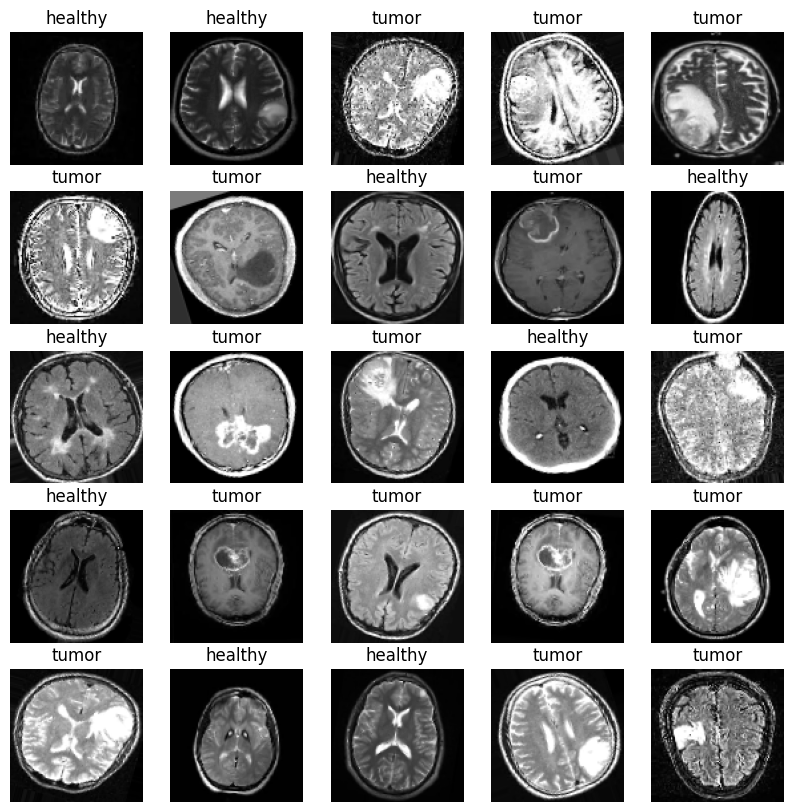

In [6]:
plt.figure(figsize=(10,10))
for i in range(1,26):
    img, label = valid_ds.next()
    plt.subplot(5,5,i)
    plt.imshow(img[0], cmap="gray")
    plt.axis('off')
    if label[0][0]==1:
        plt.title("tumor")
    else:
        plt.title("healthy")
    
    